## **1. Singling Out**

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from anonymeter.evaluators import InferenceEvaluator 
import sys
parent_dir = "/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline"
sys.path.append(parent_dir)
import pickle
seed = 42
syndatas = [f"avatarsk10_{seed}",f"ctgan_{seed}",f"gaussiancopula_{seed}",f"synthpop_{seed}",f"tvae_{seed}"]
evaluators = {}
for syndata in syndatas:
    with open(f"evaluator_singling_{syndata}_{seed}.pkl", "rb") as f:
        evaluator_singling_out = pickle.load(f)
    evaluators[syndata] = evaluator_singling_out

In [4]:
singlingout_resuls = {}
singlingout_scores = {}
cases = [1000, 5000, 10000, 18820]
dfs = []
for k, v in evaluators.items():
    risks = []
    scores = []
    for i, v_col in enumerate(v):
        res = v_col.results()
        df = pd.DataFrame(res.__dict__).drop(index=1, axis=0)
        df["Dataset"] = [k]
        df["Case"]= [cases[i]]
        dfs.append(df)
        risk = res.attack_rate.value
        score = 1 - risk
        risks.append(risk)
        scores.append(score)
    singlingout_resuls[k] = risks
    singlingout_scores[k]= scores

risk_df = pd.concat(dfs, axis = 0)
risk_df.to_csv(f"SinglingOut_Results_{seed}.csv", index = False)

/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/confidence.py:218: UserWarning: Attack is as good or worse as baseline model. Estimated rates: attack = 0.003190847190226268, baseline = 0.007189311196743562. Analysis results cannot be trusted.
  self._sanity_check()
/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/confidence.py:218: UserWarning: Attack is as good or worse as baseline model. Estimated rates: attack = 0.0030908855900633357, baseline = 0.009988236001305667. Analysis results cannot be trusted.
  self._sanity_check()
/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/confidence.py:218: UserWarning: Attack is as good or worse as baseline model. Estimated rates: attack = 0.0032908087903892004, baseline = 0.00928850480016514. Analysis results cannot be trusted.
  self._sanity_check()
/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/confidenc

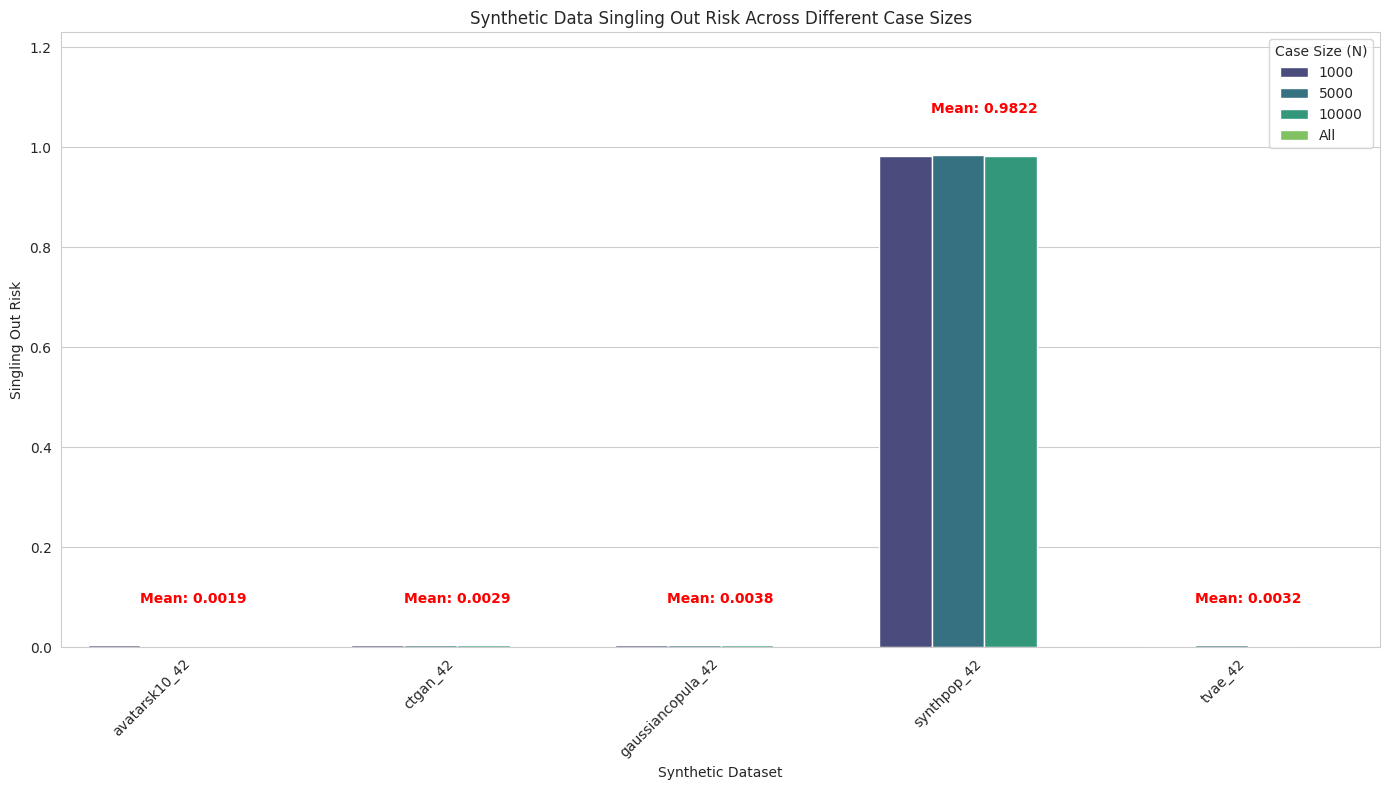

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.api.types import CategoricalDtype

# 2. Prepare DataFrame
df = pd.pivot_table(
    risk_df,
    values='attack_rate',  
    index='Case', 
    columns='Dataset', 

)
df_data_prep = df.reset_index().rename(columns={'index': 'Case'})

# Melt the DataFrame for plotting
df_data_prep['Case'] = df_data_prep['Case'].astype(str)
df_melted = df_data_prep.melt(id_vars='Case', var_name='Model', value_name='Value')

# Round the values for display labels (4 decimal places for clarity)
df_melted['Label'] = df_melted['Value'].apply(lambda x: f'{x:.4f}')

# Define explicit order for cases and models
case_order = ['1000', '5000', '10000', 'All']
model_order = list(singlingout_scores.keys())

# Calculate overall mean for each model for the group label
mean_values = df.mean(axis=0).to_dict()

# --- Plotting ---

# Set figure size and style
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Create the bar plot with explicit order
ax = sns.barplot(x='Model', y='Value', hue='Case', data=df_melted, palette='viridis',
                 hue_order=case_order, order=model_order)

# 3. Add Per-Bar Value Labels
# Create categorical types for proper sorting
case_cat_type = CategoricalDtype(categories=case_order, ordered=True)
model_cat_type = CategoricalDtype(categories=model_order, ordered=True)

df_melted['Case_ordered'] = df_melted['Case'].astype(case_cat_type)
df_melted['Model_ordered'] = df_melted['Model'].astype(model_cat_type)

# Sort by Case (hue) then Model (x) to match seaborn's bar order
df_sorted = df_melted.sort_values(by=['Case_ordered', 'Model_ordered']).reset_index(drop=True)
labels = df_sorted['Label'].tolist()

if len(labels) == len(ax.patches):
    for p, label in zip(ax.patches, labels):
        # Only annotate if the value is not zero
        if p.get_height() > 0:
            ax.annotate(label,
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom',
                        fontsize=8, color='black',
                        xytext=(0, 5),
                        textcoords='offset points',
                        rotation=90)

# 4. Add Overall Model Mean Label (with increased vertical position)
model_positions = {model: i for i, model in enumerate(model_order)}

# *** MODIFICATION START ***
new_buffer_factor = 0.08  # Increased buffer to move the mean label higher
# *** MODIFICATION END ***

for model, mean_val in mean_values.items():
    x_pos = model_positions[model]
    # Find the top of the highest bar in this model's group
    max_height = df_melted[df_melted['Model'] == model]['Value'].max()
    
    # Calculate y_pos with the increased buffer
    y_pos = max_height + new_buffer_factor * df_melted['Value'].max() 

    # Annotate the mean value for the model
    ax.annotate(f'Mean: {mean_val:.4f}',
                (x_pos, y_pos),
                ha='center', va='bottom',
                fontsize=10, color='red',
                fontweight='bold')


# 5. Set titles, labels, and save
plt.title('Synthetic Data Singling Out Risk Across Different Case Sizes')
plt.xlabel('Synthetic Dataset')
plt.ylabel('Singling Out Risk')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Case Size (N)')

# *** MODIFICATION START ***
# Adjust y-limit to accommodate the new, higher mean labels.
plt.ylim(0, df_melted['Value'].max() * 1.25) 
# *** MODIFICATION END ***

plt.tight_layout()

plt.savefig(f'Singlingout_Risk{seed}.png', dpi = 300, bbox_inches="tight")